In [2]:
from IPython.display import display, HTML
display(HTML("""
<h1 style="color:#1f77b4; text-align:center;">
SOCIAL MEDIA ENGAGEMENT ANALYTICS
</h1>    
"""))               

Project Title: Social Media Engagement Analytics

In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1)DATA IMPORT AND SETUP

df = pd.read_csv('social_media_engagement_5000.csv')

In [5]:
df = df.convert_dtypes()

In [6]:
date_cols = ['posted_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

C:\Users\Arya BS\AppData\Local\Temp\ipykernel_22400\1026217065.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [7]:
arr = df.select_dtypes(include=np.number).values
result = np.sum(arr, axis=0)

In [8]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [9]:
# 2)DATA CLEANING
#Cleaning Missing Data

print("Misssing values:\n", df.isnull().sum())

Misssing values:
 user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [10]:
df.fillna({
    'likes': int(df['likes'].median()),
    'comments': int(df['comments'].median()),
    'shares': int(df['shares'].median()),
    'age': df['age'].median(),
    'gender': df['gender'].mode()[0],
    'sentiment': df['sentiment'].mode()[0],
}, inplace=True)

In [11]:
#Duplicate Handling

df.drop_duplicates(inplace=True)

In [12]:
print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [13]:
#Data Formatting

df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

In [14]:
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [15]:
df['gender'] = df['gender'].replace({'Male': 'M', 'Female': 'F', 'male': 'M', 'female': 'F'})
df['device_type'] = df['device_type'].str.upper()

In [16]:
print(df.dtypes)

user_id                      Int64
age                          Int64
gender              string[python]
country             string[python]
post_id                      Int64
post_type           string[python]
post_category       string[python]
likes                        Int64
comments                     Int64
shares                       Int64
watch_time_sec               Int64
impression_count             Int64
posted_at           datetime64[ns]
follower_count               Int64
is_verified                boolean
device_type         string[python]
sentiment           string[python]
hashtags            string[python]
engagement_rate            Float64
dtype: object


In [17]:
#Feature Cleaning

df['hashtag_count'] = df['hashtags'].str.count('#')

In [18]:
df['sentiment'] = df['sentiment'].replace({
    'pos': 'Positive',
    'neg': 'Negative',
    'neu': 'Neutral',
    'positive': 'Positive',
    'negative': 'Negative',
    'neutral': 'Neutral'
}).str.strip()

print(df[['hashtags', 'hashtag_count', 'sentiment']].head())

                hashtags  hashtag_count sentiment
0  #foodie #travel #love              3  Negative
1               #fitness              1  Negative
2                #foodie              1  Positive
3    #music #foodie #fun              3  Negative
4                #travel              1  Negative


In [19]:
# 4)DATA EXPLORATION USING PYTHON
#View dataset structure

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

   user_id  age gender country  post_id post_type post_category  likes  \
0    25795   43      F  Brazil   496713     image       fitness   7011   
1    10860   33      M  Brazil   157326      reel          food  11750   
2    86820   32      F      UK   109864      text          food   4862   
3    64886   51  Other  France   848877      text       fitness   5350   
4    16265   34  Other      UK   449706     image       fitness  12682   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0       354    1157            5726             44650 2022-12-17   
1      2606    1807            5947             80216 2023-06-02   
2       344     955            6946             44858 2023-05-07   
3      1083    1049             229             70455 2023-02-12   
4      2735    1300            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      MOBILE  Negative  #foodie #trav

In [20]:
#Check data types and info

print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   Int64         
 1   age               5000 non-null   Int64         
 2   gender            5000 non-null   string        
 3   country           5000 non-null   string        
 4   post_id           5000 non-null   Int64         
 5   post_type         5000 non-null   string        
 6   post_category     5000 non-null   string        
 7   likes             5000 non-null   Int64         
 8   comments          5000 non-null   Int64         
 9   shares            5000 non-null   Int64         
 10  watch_time_sec    5000 non-null   Int64         
 11  impression_count  5000 non-null   Int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   Int64         
 14  is_verified       5000 n

In [21]:
#Generate summary statistics

print(df.describe())
print(df.describe(include='all'))

            user_id        age        post_id        likes    comments  \
count        5000.0     5000.0         5000.0       5000.0      5000.0   
mean     54561.8908    38.4404     548042.909   10106.9824   1502.0398   
min         10055.0       13.0       100068.0         10.0         0.0   
25%         32309.5       26.0       322543.5       5235.0       792.0   
50%         54374.5       38.0       548077.5      10105.0      1497.0   
75%         77180.5       51.0       771574.5      14959.0     2235.25   
max         99963.0       64.0       999455.0      19998.0      2999.0   
std    26090.370121  14.687151  260646.957267  5702.293022  856.393312   

          shares  watch_time_sec  impression_count  \
count     5000.0          5000.0            5000.0   
mean   1002.9106       4014.5032        50013.7328   
min          0.0             0.0             105.0   
25%        511.0         2017.75          24988.25   
50%       1012.0          4034.5           49934.5   
75%      

In [22]:
#Analyze categorical distributions

print(df['gender'].value_counts())
print(df['post_type'].unique())
print(df['country'].nunique())

gender
M        1849
Other    1581
F        1570
Name: count, dtype: Int64
<StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: string
10


In [23]:
#Correlation matrix for numeric fields

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
print(corr_matrix)

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.025811 -0.033395  0.013763   
age              -0.006688  1.000000 -0.013153 -0.036323 -0.007284  0.013871   
post_id           0.020051 -0.013153  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036323  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007284 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.013871  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013322 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.024894 -0.002844 -0.022982 -0.011733 -0.010783   
engagement_rate  -0.004282  0.008039  0.010139  0.093521  0.000051  0.021724   
hashtag_count    -0.013692  0.007173  0.007344 -0.002190 -0.015230  0.013379   

                  watch_time_sec  impre

In [24]:
#Groupby to summarize metrics

avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()
print(avg_likes_by_post_type)

print("--------------------------")

impressions_by_country = df.groupby('country')['impression_count'].sum()
print(impressions_by_country)

post_type
image    10104.852446
reel     10037.784879
text      10100.13253
video    10188.586122
Name: likes, dtype: Float64
--------------------------
country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: Int64


In [25]:
# 4)DATA WRANGLING

df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
df['hashtag_count'] = df['hashtags'].str.count('#')
group_cols = ['#']

In [26]:
group_cols = ['post_type', 'country', 'sentiment']

summary = df.groupby(group_cols).agg({
    'engagement_score': 'sum',
    'likes': ['mean', 'median'],
    'comments': 'sum',
    'shares': 'max',
    'watch_time_sec': 'mean',
    'engagement_rate': 'mean',
    'follower_count': 'sum'
}).reset_index()

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]

print(summary.head())

  post_type_   country_ sentiment_  engagement_score_sum   likes_mean  \
0      image  Australia   Negative                191572  8006.105263   
1      image  Australia    Neutral                527418  9683.666667   
2      image  Australia   Positive                849737  10234.69697   
3      image     Brazil   Negative                204376      7559.35   
4      image     Brazil    Neutral                509793  8409.608696   

   likes_median  comments_sum  shares_max  watch_time_sec_mean  \
0        9559.0         20559        1989               3534.0   
1        9882.0         72116        1989          4132.190476   
2       10871.0        103268        1988          4097.651515   
3        6810.5         32988        1919               4401.2   
4        8402.5         71152        1984          4092.826087   

   engagement_rate_mean  follower_count_sum  
0               0.48127             8478813  
1              1.039867            15579118  
2              0.917317   

In [27]:
# 5)STATISTICAL ANALYSIS

cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

stats_df = df[cols].agg([
    'mean',
    'median',
    lambda x: x.mode().iloc[0],
    'std',
    'var',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75)
])

stats_df.index = ['mean', 'median', 'mode', 'std_dev', 'variance', '25%', '50%', '75%']

print(stats_df)

                 likes       comments        shares  watch_time_sec  \
mean      1.010698e+04    1502.039800    1002.91060    4.014503e+03   
median    1.010500e+04    1497.000000    1012.00000    4.034500e+03   
mode      1.010500e+04    1497.000000    1012.00000    9.160000e+02   
std_dev   5.702293e+03     856.393312     570.85520    2.308096e+03   
variance  3.251615e+07  733409.504917  325875.65934    5.327309e+06   
25%       5.235000e+03     792.000000     511.00000    2.017750e+03   
50%       1.010500e+04    1497.000000    1012.00000    4.034500e+03   
75%       1.495900e+04    2235.250000    1483.00000    6.020250e+03   

          engagement_rate  follower_count  
mean             0.964356    3.936982e+05  
median           0.253896    3.889820e+05  
mode             0.006363    4.975020e+05  
std_dev          5.318029    2.309279e+05  
variance        28.281435    5.332769e+10  
25%              0.145781    1.944800e+05  
50%              0.253896    3.889820e+05  
75%     

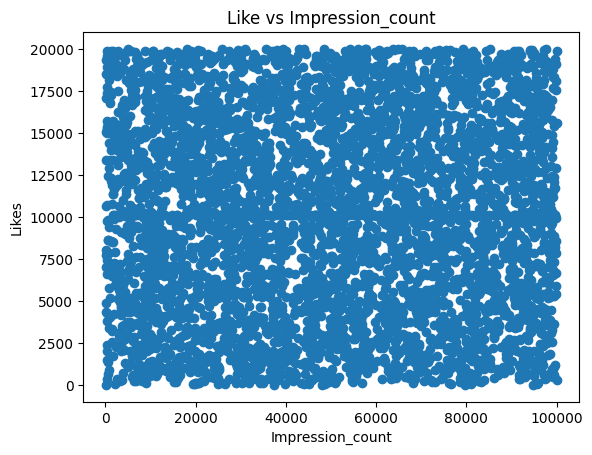

In [28]:
# 6)DATA VISUALIZATION
    #Matplotlib

# Scatter: likes vs impressions
plt.scatter(df['impression_count'], df['likes'])
plt.xlabel('Impression_count')
plt.ylabel('Likes')
plt.title('Like vs Impression_count')
plt.show()


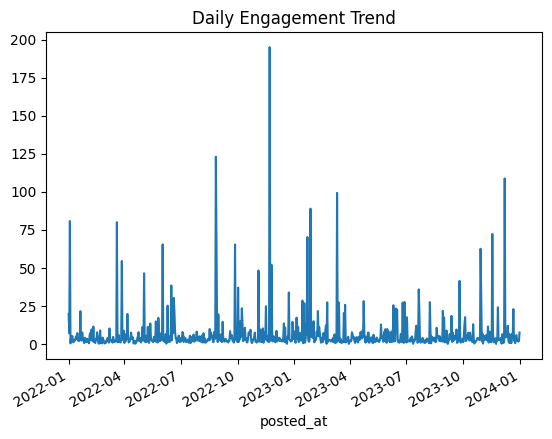

In [29]:
# Line: daily engagement trend

df.groupby('posted_at')['engagement_rate'].sum().plot()
plt.title('Daily Engagement Trend')
plt.show()

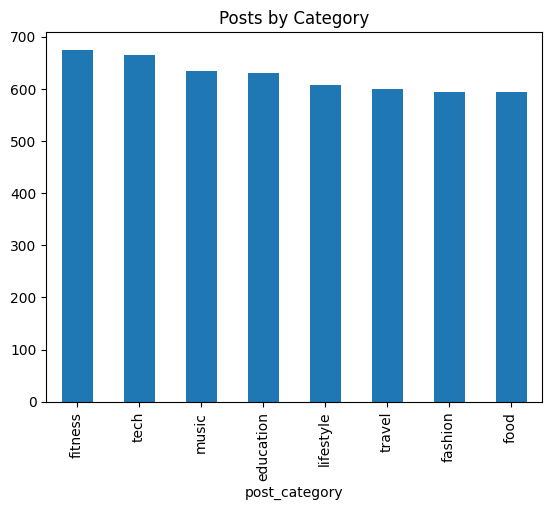

In [30]:
# Bar: posts by category

df['post_category'].value_counts().plot(kind='bar')
plt.title('Posts by Category')
plt.show()

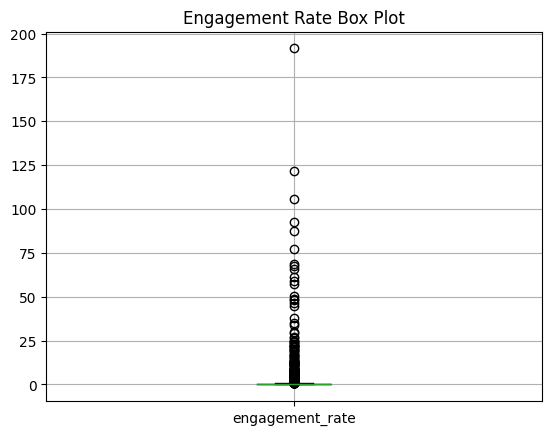

In [31]:
# Box: engagement rate

df.boxplot(column='engagement_rate')
plt.title('Engagement Rate Box Plot')
plt.show()

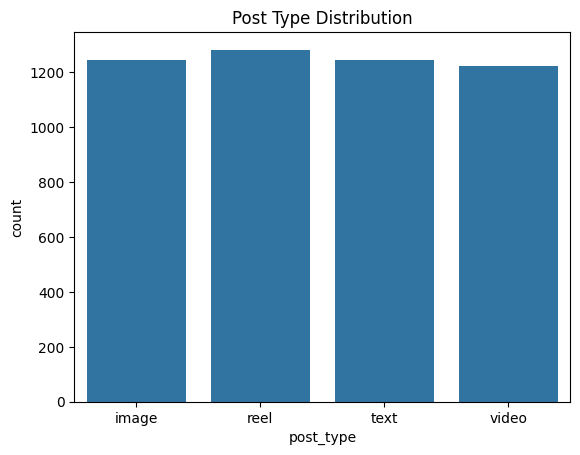

In [32]:
    #Seaborn
# Count plot: post type

sns.countplot(x='post_type', data=df)
plt.title('Post Type Distribution')
plt.show()


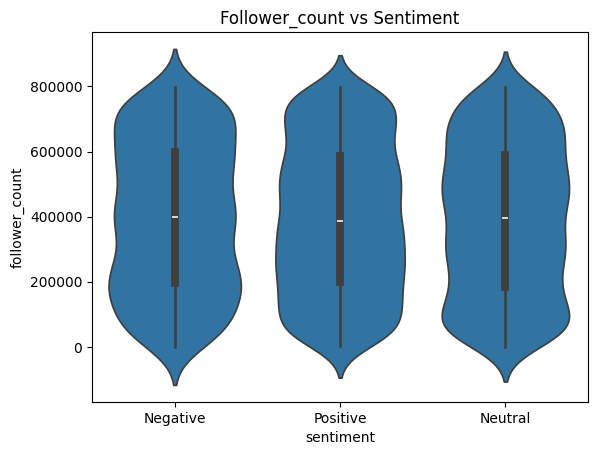

In [33]:
# violin: followers vs sentiment

sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.title('Follower_count vs Sentiment')
plt.show()

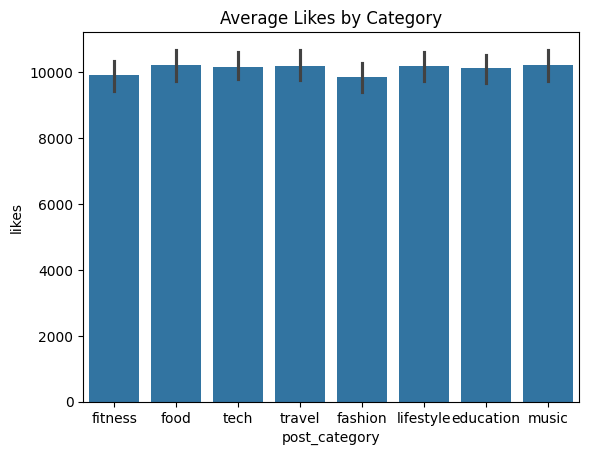

In [34]:
# Bar plot: avg likes by category

sns.barplot(x='post_category', y='likes', data=df, estimator=np.mean)
plt.title('Average Likes by Category')
plt.show()

In [35]:
    #Plotly(Interactive)
import plotly.express as px

In [36]:
# Interactive scatter

fig = px.scatter(df, x='impression_count', y='likes', title='Likes vs Impression_count')
fig.show()

In [37]:
# Interactive bar chart

fig = px.bar(df['post_category'].value_counts().reset_index(), x='post_category', y='count', title='Posts by Category')
fig.show()

In [38]:
# FINAL INSIGHTS
    # Content Performance 

print("Post type with highest engagement:")

top_posts = (
    df.groupby('post_type')[['likes', 'comments', 'shares']].sum().sum(axis=1).sort_values(ascending=False))

print(top_posts)

Post type with highest engagement:
post_type
reel     16068310
image    15773774
text     15703469
video    15514111
dtype: Int64


Insight: The analysis reveals that reels are the most engaging post type among image, video and text. Posts categorized as reel 
         generate the highest engagement.

In [39]:
print("\nBest content category (avg engagement rate):")
print(df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False).head())


Best content category (avg engagement rate):
post_category
food         1.358628
tech         1.160475
lifestyle    1.091019
music        0.888803
fitness      0.865628
Name: engagement_rate, dtype: Float64


Insight: The analysis shows that food is the top-performing content category among tech, lifestyle, music and fitness. Posts tagged with the food category have the highest average engagement rate.

In [40]:
print("\nCountries with highest avg engagement rate:")
print(df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False).head())


Countries with highest avg engagement rate:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
Name: engagement_rate, dtype: Float64


Insight: The analysis reveals that Brazil has the highest average engagement rate among Australia, France, UAE and Canada. 

In [41]:
    # User Trends
print("Age impact on engagement:")
print(df.groupby('age')['engagement_rate'].mean().sort_values(ascending=False))

Age impact on engagement:
age
24    2.897327
55    2.599106
51    2.397295
48    1.675878
50    1.552627
41     1.54007
35    1.521596
47    1.402015
42    1.350772
63    1.303909
33    1.277557
30    1.270129
16    1.226848
29    1.110432
25    1.041681
38    1.035114
62    1.005127
14    1.003067
54    1.002622
49    0.999235
40    0.930504
23    0.922448
57    0.919751
18    0.888391
52    0.867426
17    0.858763
44    0.795102
27    0.775328
60    0.759586
15     0.71417
53    0.707924
19    0.676687
46    0.663994
36    0.609569
22    0.586786
32     0.58171
43    0.566439
34    0.557236
61    0.553854
56    0.524008
20    0.515541
45    0.513521
26    0.501467
59    0.495578
37    0.494109
13    0.455583
21    0.452752
31    0.440684
39    0.436184
58     0.43513
64    0.402533
28    0.385081
Name: engagement_rate, dtype: Float64


Insight: Age has a noticeable impact on engagement rates. The data shows the younger adults, especially those around age 24, experience the highest engagement. As age increases, the engagement generally declines, through some older age groups (55 and 51) show relatively higher rates compared to their neighbors.

In [42]:
print("\nVerified vs non-verified engagement rate:")
print(df.groupby('is_verified')['engagement_rate'].mean())


Verified vs non-verified engagement rate:
is_verified
False    0.954744
True      1.05425
Name: engagement_rate, dtype: Float64


Insight: The analysys shows that verified accounts have a slightly higher average engagement rate compared to non-verified accounts. This indicates that verified profiles generate about 10.5% more engagement on average than non-verified profiles, suggesting that verification can boost audience interaction.

In [43]:
# Behavioral Insights

df['post_hour'] = pd.to_datetime(df['posted_at']).dt.hour

print("Best hour for impressions:")
print(df.groupby('post_hour')['impression_count'].mean().sort_values(ascending=False))

Best hour for impressions:
post_hour
0    50013.7328
Name: impression_count, dtype: Float64


Insight: The analysis indicates that the hour of the day with the highest average impression count is *hour 0* with an average of **50013.7328** impressions.

In [44]:
print("\nDevice type impact on watch time:")
print(df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False))


Device type impact on watch time:
device_type
MOBILE      4087.83076
TABLET     3979.736429
DESKTOP    3974.792521
Name: watch_time_sec, dtype: Float64


Insight: Mobile devices have the highest average watch time, followed by tablets and desktop. Users spend more time watching on mobile compared to other devices.

In [45]:
# Sentiment Analysis 

df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

In [46]:
sentiment_performance = (df.groupby('sentiment')['total_engagement'].mean().sort_values(ascending=False))

print("Average engagement by sentiment:")
print(sentiment_performance)

best_sentiment = sentiment_performance.idxmax()
print("\nSentiment with best performance:", best_sentiment)

Average engagement by sentiment:
sentiment
Negative    12731.483333
Positive    12665.784322
Neutral     12448.149312
Name: total_engagement, dtype: Float64

Sentiment with best performance: Negative


Insight: The sentiment that performs best is negative, as it records the highest average engagement among all sentiment categories.

In [47]:
df['sentiment'].value_counts()

df['sentiment'] = df['sentiment'].str.strip().str.lower()

neg_neu_behavior = ( df[df['sentiment'].isin(['negative', 'neutral'])]
                    .groupby('sentiment')[['total_engagement', 'watch_time_sec', 'impression_count']].mean())

print("Behavior of negative and neutral sentiment posts:")
print(neg_neu_behavior)

Behavior of negative and neutral sentiment posts:
           total_engagement  watch_time_sec  impression_count
sentiment                                                    
negative       12731.483333     4054.639583      50191.960417
neutral        12448.149312     4031.823183      49515.971185


Sentiment Performance Analysis:

Among all sentiment categories, **negative sentiment posts perform best**, recording the highest average engagement (likes, comments and shares). 

Further analysis of negative and neutral sentiment posts shows distinct behavior patterns. Negative posts tend to generate higher engagement, while neutral posts exhibit moderate interaction and stable reach.